In [2]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import plotly.express as px

In [44]:
df_merge = pd.read_csv('../LFB_project_data/output/merged_dataset.csv')
df_merge_neu = pd.read_csv('../LFB_project_data/merged_dataset.csv')

In [5]:
df_merge.head()

,IncidentNumber,CalYear,HourOfCall,DateAndTimeMobilised,AttendanceTimeSeconds,DeployedFromStation_Name,PumpOrder,DateOfCall,IncidentGroup,SpecialServiceType,PropertyCategory,PropertyType,IncGeo_BoroughName,NumCalls,Latitude,Longitude,is_special_service,distance_fire_to_station,distance_fire_to_city_center,avg_speed
0,000004-01012021,2021,0,01/01/2021 00:06,181,HORNSEY,1,2021-01-01,False Alarm,NoSpecialService,Non Residential,Single shop,HARINGEY,1.0,51.590249,-0.143203,0,NaN,NaN,NaN
1,000005-01012021,2021,0,01/01/2021 00:07,250,WOODFORD,1,2021-01-01,Fire,NoSpecialService,Outdoor,Tree scrub,REDBRIDGE,1.0,51.606914,0.030447,0,NaN,NaN,NaN
2,000006-01012021,2021,0,01/01/2021 00:08,376,DAGENHAM,1,2021-01-01,False Alarm,NoSpecialService,Outdoor,Road surface/pavement,BARKING AND DAGENHAM,1.0,51.540143,0.154479,0,NaN,NaN,NaN
3,000007-01012021,2021,0,01/01/2021 00:12,409,WANDSWORTH,1,2021-01-01,False Alarm,NoSpecialService,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,WANDSWORTH,4.0,51.446439,-0.214895,0,NaN,NaN,NaN
4,000007-01012021,2021,0,01/01/2021 00:12,445,FULHAM,2,2021-01-01,False Alarm,NoSpecialService,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,WANDSWORTH,4.0,51.446439,-0.214895,0,NaN,NaN,NaN


In [6]:
df_merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 952270 entries, 0 to 952269
Data columns (total 20 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   IncidentNumber                952270 non-null  str    
 1   CalYear                       952270 non-null  int64  
 2   HourOfCall                    952270 non-null  int64  
 3   DateAndTimeMobilised          952270 non-null  str    
 4   AttendanceTimeSeconds         952270 non-null  int64  
 5   DeployedFromStation_Name      952270 non-null  str    
 6   PumpOrder                     952270 non-null  int64  
 7   DateOfCall                    952270 non-null  str    
 8   IncidentGroup                 952270 non-null  str    
 9   SpecialServiceType            952270 non-null  str    
 10  PropertyCategory              952270 non-null  str    
 11  PropertyType                  952270 non-null  str    
 12  IncGeo_BoroughName            952270 non-null  str    


In [7]:
df_merge.isna().sum()

IncidentNumber                       0
CalYear                              0
HourOfCall                           0
DateAndTimeMobilised                 0
AttendanceTimeSeconds                0
DeployedFromStation_Name             0
PumpOrder                            0
DateOfCall                           0
IncidentGroup                        0
SpecialServiceType                   0
PropertyCategory                     0
PropertyType                         0
IncGeo_BoroughName                   0
NumCalls                             0
Latitude                             0
Longitude                            0
is_special_service                   0
distance_fire_to_station        952270
distance_fire_to_city_center    952270
avg_speed                       952270
dtype: int64

In [8]:
df_merge['IncidentGroup'].unique()

<StringArray>
['False Alarm', 'Fire', 'Special Service']
Length: 3, dtype: str

In [10]:

invalid_mask = (df_merge['IncidentGroup'] == 'Special Service') & \
               (df_merge['SpecialServiceType'].isin(['NoSpecialService', None]) | df_merge['SpecialServiceType'].isna())

invalid_cases = df_merge[invalid_mask]

print(f"Anzahl fehlerhafter Einträge: {len(invalid_cases)}")
if not invalid_cases.empty:
    print(invalid_cases[['IncidentGroup', 'SpecialServiceType']].head())

Anzahl fehlerhafter Einträge: 17
          IncidentGroup SpecialServiceType
840497  Special Service   NoSpecialService
846960  Special Service   NoSpecialService
850796  Special Service   NoSpecialService
851423  Special Service   NoSpecialService
852225  Special Service   NoSpecialService


In [ ]:
#deleate columns in incident file

cols_to_drop_inc = [
    'TimeOfCall', 'StopCodeDescription', 'AddressQualifier', 'Postcode_full', 
    'Postcode_district', 'UPRN', 'USRN', 'IncGeo_BoroughCode', 'ProperCase', 
    'IncGeo_WardCode', 'IncGeo_WardName', 'IncGeo_WardNameNew', 'Latitude', 
    'Longitude', 'FRS', 'IncidentStationGround', 'FirstPumpArriving_AttendanceTime', 
    'FirstPumpArriving_DeployedFromStation', 'SecondPumpArriving_AttendanceTime', 
    'SecondPumpArriving_DeployedFromStation', 'NumStationsWithPumpsAttending', 
    'NumPumpsAttending', 'PumpCount', 'PumpMinutesRounded', 'Notional Cost (£)'
]

inc_trunc = inc_trunc.drop(columns=cols_to_drop_inc)
print(inc_trunc.columns)

Index(['IncidentNumber', 'DateOfCall', 'CalYear', 'HourOfCall',
       'IncidentGroup', 'SpecialServiceType', 'PropertyCategory',
       'PropertyType', 'IncGeo_BoroughName', 'Easting_m', 'Northing_m',
       'Easting_rounded', 'Northing_rounded', 'NumCalls', 'source_file'],
      dtype='object')


In [12]:
df_merge.tail()

,IncidentNumber,CalYear,HourOfCall,DateAndTimeMobilised,AttendanceTimeSeconds,DeployedFromStation_Name,PumpOrder,DateOfCall,IncidentGroup,SpecialServiceType,PropertyCategory,PropertyType,IncGeo_BoroughName,NumCalls,Latitude,Longitude,is_special_service,distance_fire_to_station,distance_fire_to_city_center,avg_speed
952265,056721-31032026,2026,0,30/03/2026 23:37,227,HORNSEY,2,2026-03-31,False Alarm,NoSpecialService,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,HARINGEY,1.0,51.589662,-0.115451,0,NaN,NaN,NaN
952266,056721-31032026,2026,0,30/03/2026 23:37,203,HORNSEY,1,2026-03-31,False Alarm,NoSpecialService,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,HARINGEY,1.0,51.589662,-0.115451,0,NaN,NaN,NaN
952267,056721-31032026,2026,0,30/03/2026 23:37,285,TOTTENHAM,3,2026-03-31,False Alarm,NoSpecialService,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,HARINGEY,1.0,51.589662,-0.115451,0,NaN,NaN,NaN
952268,056721-31032026,2026,0,30/03/2026 23:37,485,HOLLOWAY,4,2026-03-31,False Alarm,NoSpecialService,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,HARINGEY,1.0,51.589662,-0.115451,0,NaN,NaN,NaN
952269,056721-31032026,2026,0,30/03/2026 23:37,563,TOTTENHAM,5,2026-03-31,False Alarm,NoSpecialService,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,HARINGEY,1.0,51.589662,-0.115451,0,NaN,NaN,NaN


In [15]:
df_merge['PropertyType'].value_counts()

PropertyType
Purpose Built Flats/Maisonettes - 4 to 9 storeys         179960
Purpose Built Flats/Maisonettes - Up to 3 storeys        112617
House - single occupancy                                 108741
Purpose Built Flats/Maisonettes - 10 or more storeys      64133
Self contained Sheltered Housing                          50912
                                                          ...  
Milking Parlour                                               3
Racecourse                                                    1
Military plane                                                1
Greenhouse (commercial) polytunnel                            1
Naval vessel                                                  1
Name: count, Length: 286, dtype: int64

In [16]:
df_merge.tail(5)

,IncidentNumber,CalYear,HourOfCall,DateAndTimeMobilised,AttendanceTimeSeconds,DeployedFromStation_Name,PumpOrder,DateOfCall,IncidentGroup,SpecialServiceType,PropertyCategory,PropertyType,IncGeo_BoroughName,NumCalls,Latitude,Longitude,is_special_service,distance_fire_to_station,distance_fire_to_city_center,avg_speed
952265,056721-31032026,2026,0,30/03/2026 23:37,227,HORNSEY,2,2026-03-31,False Alarm,NoSpecialService,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,HARINGEY,1.0,51.589662,-0.115451,0,NaN,NaN,NaN
952266,056721-31032026,2026,0,30/03/2026 23:37,203,HORNSEY,1,2026-03-31,False Alarm,NoSpecialService,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,HARINGEY,1.0,51.589662,-0.115451,0,NaN,NaN,NaN
952267,056721-31032026,2026,0,30/03/2026 23:37,285,TOTTENHAM,3,2026-03-31,False Alarm,NoSpecialService,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,HARINGEY,1.0,51.589662,-0.115451,0,NaN,NaN,NaN
952268,056721-31032026,2026,0,30/03/2026 23:37,485,HOLLOWAY,4,2026-03-31,False Alarm,NoSpecialService,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,HARINGEY,1.0,51.589662,-0.115451,0,NaN,NaN,NaN
952269,056721-31032026,2026,0,30/03/2026 23:37,563,TOTTENHAM,5,2026-03-31,False Alarm,NoSpecialService,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,HARINGEY,1.0,51.589662,-0.115451,0,NaN,NaN,NaN


In [17]:
df_merge['PumpOrder'].nunique()

13

In [18]:
print((df_merge['PumpOrder'] == 1).sum())

613927


In [19]:
df_distance = pd.read_csv('../LFB_project_data/computed_distance.csv')

In [21]:
df_distance.head()

common_count = len(set(df_merge['IncidentNumber']).intersection(set(df_distance['IncidentNumber'])))
print(f"Anzahl gemeinsamer IncidentNumbers: {common_count}")

Anzahl gemeinsamer IncidentNumbers: 99025


In [22]:
df_distance.head()

,Unnamed: 0,IncidentNumber,DateOfCall,CalYear,TimeOfCall,IncidentGroup,IncGeo_BoroughName,Latitude,Longitude,FirstPumpArriving_DeployedFromStation,Station_Lat,Station_Long,Distance_from_First_Station
0,0,000004-01012021,2021-01-01,2021,00:06:47,False Alarm,HARINGEY,51.590253,-0.143174,Hornsey,51.586484,-0.127589,1490.3
1,1,000005-01012021,2021-01-01,2021,00:07:46,Fire,REDBRIDGE,51.606923,0.030486,Woodford,51.609446,0.023929,1168.4
2,2,000006-01012021,2021-01-01,2021,00:08:21,False Alarm,BARKING AND DAGENHAM,51.540145,0.154515,Dagenham,51.559108,0.156820,3450.5
3,3,000009-01012021,2021-01-01,2021,00:14:51,Fire,NEWHAM,51.547249,0.023585,Stratford,51.543262,0.011043,1049.8
4,4,000015-01012021,2021-01-01,2021,00:16:27,Fire,MERTON,51.407446,-0.177207,Mitcham,51.397260,-0.172823,1675.6


In [27]:

display(df_merge[df_merge['IncidentGroup'] == 'Special Service'].head(5))

,IncidentNumber,CalYear,HourOfCall,DateAndTimeMobilised,AttendanceTimeSeconds,DeployedFromStation_Name,PumpOrder,DateOfCall,IncidentGroup,SpecialServiceType,PropertyCategory,PropertyType,IncGeo_BoroughName,NumCalls,Latitude,Longitude,is_special_service,distance_fire_to_station,distance_fire_to_city_center,avg_speed
26,000032-01012021,2021,0,01/01/2021 00:23,720,NORTHOLT,1,2021-01-01,Special Service,Lift Release,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,HARROW,2.0,51.579498,-0.335251,1,NaN,NaN,NaN
53,000032-01012021,2021,0,01/01/2021 00:36,47,HARROW,2,2021-01-01,Special Service,Lift Release,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,HARROW,2.0,51.579498,-0.335251,1,NaN,NaN,NaN
79,000098-01012021,2021,1,01/01/2021 01:05,516,PLUMSTEAD,1,2021-01-01,Special Service,Lift Release,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,GREENWICH,3.0,51.504758,0.117361,1,NaN,NaN,NaN
116,000152-01012021,2021,2,01/01/2021 02:18,221,SHADWELL,1,2021-01-01,Special Service,RTC,Road Vehicle,Car,TOWER HAMLETS,1.0,51.509601,-0.055334,1,NaN,NaN,NaN
117,000152-01012021,2021,2,01/01/2021 02:18,242,WHITECHAPEL,2,2021-01-01,Special Service,RTC,Road Vehicle,Car,TOWER HAMLETS,1.0,51.509601,-0.055334,1,NaN,NaN,NaN


In [28]:
df_merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 952270 entries, 0 to 952269
Data columns (total 20 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   IncidentNumber                952270 non-null  str    
 1   CalYear                       952270 non-null  int64  
 2   HourOfCall                    952270 non-null  int64  
 3   DateAndTimeMobilised          952270 non-null  str    
 4   AttendanceTimeSeconds         952270 non-null  int64  
 5   DeployedFromStation_Name      952270 non-null  str    
 6   PumpOrder                     952270 non-null  int64  
 7   DateOfCall                    952270 non-null  str    
 8   IncidentGroup                 952270 non-null  str    
 9   SpecialServiceType            952270 non-null  str    
 10  PropertyCategory              952270 non-null  str    
 11  PropertyType                  952270 non-null  str    
 12  IncGeo_BoroughName            952270 non-null  str    


In [38]:
df_merge['PropertyType'].value_counts()

PropertyType
Purpose Built Flats/Maisonettes - 4 to 9 storeys         179960
Purpose Built Flats/Maisonettes - Up to 3 storeys        112617
House - single occupancy                                 108741
Purpose Built Flats/Maisonettes - 10 or more storeys      64133
Self contained Sheltered Housing                          50912
                                                          ...  
Milking Parlour                                               3
Racecourse                                                    1
Military plane                                                1
Greenhouse (commercial) polytunnel                            1
Naval vessel                                                  1
Name: count, Length: 286, dtype: int64

In [42]:
df_merge.describe()

,CalYear,HourOfCall,AttendanceTimeSeconds,PumpOrder,NumCalls,Latitude,Longitude,is_special_service,distance_fire_to_station,distance_fire_to_city_center,avg_speed
count,952270.000000,952270.000000,952270.000000,952270.000000,952270.000000,952270.000000,952270.000000,952270.000000,0.0,0.0,0.0
mean,2023.268085,13.342128,360.766387,1.549412,1.371348,51.507549,-0.119303,0.255400,NaN,NaN,NaN
std,1.505205,6.428797,152.982435,0.928576,1.929321,0.066043,0.137870,0.436086,NaN,NaN,NaN
min,2021.000000,0.000000,0.000000,1.000000,1.000000,51.287213,-0.510094,0.000000,NaN,NaN,NaN
25%,2022.000000,9.000000,259.000000,1.000000,1.000000,51.469243,-0.194547,0.000000,NaN,NaN,NaN
50%,2023.000000,14.000000,338.000000,1.000000,1.000000,51.514060,-0.114201,0.000000,NaN,NaN,NaN
75%,2025.000000,19.000000,436.000000,2.000000,1.000000,51.549773,-0.037589,1.000000,NaN,NaN,NaN
max,2026.000000,23.000000,1200.000000,13.000000,210.000000,51.691454,0.322181,1.000000,NaN,NaN,NaN


In [43]:
df_merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 952270 entries, 0 to 952269
Data columns (total 20 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   IncidentNumber                952270 non-null  str    
 1   CalYear                       952270 non-null  int64  
 2   HourOfCall                    952270 non-null  int64  
 3   DateAndTimeMobilised          952270 non-null  str    
 4   AttendanceTimeSeconds         952270 non-null  int64  
 5   DeployedFromStation_Name      952270 non-null  str    
 6   PumpOrder                     952270 non-null  int64  
 7   DateOfCall                    952270 non-null  str    
 8   IncidentGroup                 952270 non-null  str    
 9   SpecialServiceType            952270 non-null  str    
 10  PropertyCategory              952270 non-null  str    
 11  PropertyType                  952270 non-null  str    
 12  IncGeo_BoroughName            952270 non-null  str    


In [45]:
df_merge_neu.info()

<class 'pandas.DataFrame'>
RangeIndex: 608941 entries, 0 to 608940
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   IncidentNumber            608941 non-null  str    
 1   CalYear                   608941 non-null  int64  
 2   Month                     608941 non-null  int64  
 3   Weekday                   608941 non-null  int64  
 4   Hour                      608941 non-null  int64  
 5   Is_Nightshift             608941 non-null  int64  
 6   Is_Rush_Hour              608941 non-null  int64  
 7   Is_Weekend                608941 non-null  int64  
 8   Is_Public_Holiday         608941 non-null  int64  
 9   AttendanceTimeSeconds     608941 non-null  int64  
 10  DeployedFromStation_Name  608941 non-null  str    
 11  PumpOrder                 608941 non-null  int64  
 12  IncidentGroup             608941 non-null  str    
 13  Is_SpecialService         608941 non-null  int64  
 14 

In [46]:
df_merge_neu.head()

,IncidentNumber,CalYear,Month,Weekday,Hour,Is_Nightshift,Is_Rush_Hour,Is_Weekend,Is_Public_Holiday,AttendanceTimeSeconds,...,PropertyCategory,PropertyType,IncGeo_BoroughName,NumCalls,Is_RepeatedCall,Latitude,Longitude,distance_fire_to_station,avg_speed,NumOfCalls_bucket
0,000004-01012021,2021,1,4,0,1,0,0,1,181,...,Non Residential,Single shop,HARINGEY,1.0,0,51.590249,-0.143203,1490.3,50,1
1,000005-01012021,2021,1,4,0,1,0,0,1,250,...,Outdoor,Tree scrub,REDBRIDGE,1.0,0,51.606914,0.030447,1168.4,50,1
2,000006-01012021,2021,1,4,0,1,0,0,1,376,...,Outdoor,Road surface/pavement,BARKING AND DAGENHAM,1.0,0,51.540143,0.154479,3450.5,50,1
3,000007-01012021,2021,1,4,0,1,0,0,1,409,...,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,WANDSWORTH,4.0,1,51.446439,-0.214895,20.0,50,4-5
4,000009-01012021,2021,1,4,0,1,0,0,1,362,...,Road Vehicle,Car,NEWHAM,2.0,1,51.547241,0.023549,1049.8,50,2


In [47]:
df_merge_neu.describe()

,CalYear,Month,Weekday,Hour,Is_Nightshift,Is_Rush_Hour,Is_Weekend,Is_Public_Holiday,AttendanceTimeSeconds,PumpOrder,Is_SpecialService,NumCalls,Is_RepeatedCall,Latitude,Longitude,distance_fire_to_station,avg_speed
count,608941.000000,608941.000000,608941.000000,608941.000000,608941.000000,608941.000000,608941.000000,608941.000000,608941.000000,608941.0,608941.000000,608941.000000,608941.000000,608941.000000,608941.000000,608941.000000,608941.0
mean,2023.253657,6.451366,3.015928,13.197300,0.174464,0.346756,0.288476,0.020076,321.947956,1.0,0.355676,1.301070,0.163349,51.507825,-0.118947,406.338717,50.0
std,1.501499,3.483442,1.995890,6.263089,0.379508,0.475938,0.453054,0.140260,127.289049,0.0,0.478718,1.483069,0.369684,0.067776,0.141413,1107.625485,0.0
min,2021.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,1.0,0.000000,1.000000,0.000000,51.287213,-0.510094,-1.000000,50.0
25%,2022.000000,3.000000,1.000000,9.000000,0.000000,0.000000,0.000000,0.000000,237.000000,1.0,0.000000,1.000000,0.000000,51.467576,-0.196509,20.000000,50.0
50%,2023.000000,7.000000,3.000000,14.000000,0.000000,0.000000,0.000000,0.000000,303.000000,1.0,0.000000,1.000000,0.000000,51.514401,-0.114054,20.000000,50.0
75%,2025.000000,9.000000,5.000000,18.000000,0.000000,1.000000,1.000000,0.000000,384.000000,1.0,1.000000,1.000000,0.000000,51.551997,-0.035759,20.000000,50.0
max,2026.000000,12.000000,6.000000,23.000000,1.000000,1.000000,1.000000,1.000000,782.000000,1.0,1.000000,210.000000,1.000000,51.691454,0.322181,67136.100000,50.0


In [49]:
df_merge_neu['PumpOrder'].unique()

array([1])

In [50]:
df_merge_neu.info()

<class 'pandas.DataFrame'>
RangeIndex: 608941 entries, 0 to 608940
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   IncidentNumber            608941 non-null  str    
 1   CalYear                   608941 non-null  int64  
 2   Month                     608941 non-null  int64  
 3   Weekday                   608941 non-null  int64  
 4   Hour                      608941 non-null  int64  
 5   Is_Nightshift             608941 non-null  int64  
 6   Is_Rush_Hour              608941 non-null  int64  
 7   Is_Weekend                608941 non-null  int64  
 8   Is_Public_Holiday         608941 non-null  int64  
 9   AttendanceTimeSeconds     608941 non-null  int64  
 10  DeployedFromStation_Name  608941 non-null  str    
 11  PumpOrder                 608941 non-null  int64  
 12  IncidentGroup             608941 non-null  str    
 13  Is_SpecialService         608941 non-null  int64  
 14 

In [52]:
df_merge_neu.head(5)

,IncidentNumber,CalYear,Month,Weekday,Hour,Is_Nightshift,Is_Rush_Hour,Is_Weekend,Is_Public_Holiday,AttendanceTimeSeconds,...,PropertyCategory,PropertyType,IncGeo_BoroughName,NumCalls,Is_RepeatedCall,Latitude,Longitude,distance_fire_to_station,avg_speed,NumOfCalls_bucket
0,000004-01012021,2021,1,4,0,1,0,0,1,181,...,Non Residential,Single shop,HARINGEY,1.0,0,51.590249,-0.143203,1490.3,50,1
1,000005-01012021,2021,1,4,0,1,0,0,1,250,...,Outdoor,Tree scrub,REDBRIDGE,1.0,0,51.606914,0.030447,1168.4,50,1
2,000006-01012021,2021,1,4,0,1,0,0,1,376,...,Outdoor,Road surface/pavement,BARKING AND DAGENHAM,1.0,0,51.540143,0.154479,3450.5,50,1
3,000007-01012021,2021,1,4,0,1,0,0,1,409,...,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,WANDSWORTH,4.0,1,51.446439,-0.214895,20.0,50,4-5
4,000009-01012021,2021,1,4,0,1,0,0,1,362,...,Road Vehicle,Car,NEWHAM,2.0,1,51.547241,0.023549,1049.8,50,2


In [53]:
df_merge_neu.info()

<class 'pandas.DataFrame'>
RangeIndex: 608941 entries, 0 to 608940
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   IncidentNumber            608941 non-null  str    
 1   CalYear                   608941 non-null  int64  
 2   Month                     608941 non-null  int64  
 3   Weekday                   608941 non-null  int64  
 4   Hour                      608941 non-null  int64  
 5   Is_Nightshift             608941 non-null  int64  
 6   Is_Rush_Hour              608941 non-null  int64  
 7   Is_Weekend                608941 non-null  int64  
 8   Is_Public_Holiday         608941 non-null  int64  
 9   AttendanceTimeSeconds     608941 non-null  int64  
 10  DeployedFromStation_Name  608941 non-null  str    
 11  PumpOrder                 608941 non-null  int64  
 12  IncidentGroup             608941 non-null  str    
 13  Is_SpecialService         608941 non-null  int64  
 14 

In [55]:
df_merge_neu['distance_fire_to_station'].value_counts().head(5)

distance_fire_to_station
 20.0      511287
-1.0          323
 2285.5        44
 1264.9        41
 2301.1        39
Name: count, dtype: int64

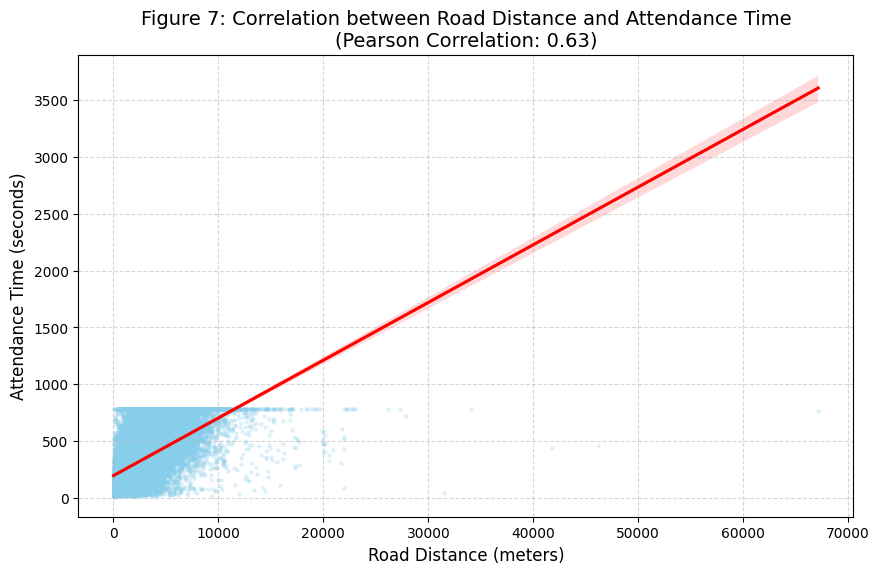

In [56]:
# 1. Daten filtern: RoadDistance 20 entfernen (Default-Wert/Fehler)
# Und zusätzlich deine Funktion für die Zeit-Ausreißer anwenden
df_plot = df_merge_neu[df_merge_neu['distance_fire_to_station'] > 20].copy()


# 2. Den Plot erstellen
plt.figure(figsize=(10, 6))

# Jointplot oder regplot sind ideal, um die Korrelation zu zeigen
sns.regplot(data=df_plot, 
            x='distance_fire_to_station', 
            y='AttendanceTimeSeconds',
            scatter_kws={'alpha':0.2, 's':5, 'color': 'skyblue'}, # Transparenz bei vielen Daten
            line_kws={'color':'red'})

# 3. Korrelation berechnen (für den Titel)
corr_value = df_plot['distance_fire_to_station'].corr(df_plot['AttendanceTimeSeconds'])

# 4. Beschriftung
plt.title(f'Figure 7: Correlation between Road Distance and Attendance Time\n(Pearson Correlation: {corr_value:.2f})', fontsize=14)
plt.xlabel('Road Distance (meters)', fontsize=12)
plt.ylabel('Attendance Time (seconds)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [57]:
df_merge_neu.describe()

,CalYear,Month,Weekday,Hour,Is_Nightshift,Is_Rush_Hour,Is_Weekend,Is_Public_Holiday,AttendanceTimeSeconds,PumpOrder,Is_SpecialService,NumCalls,Is_RepeatedCall,Latitude,Longitude,distance_fire_to_station,avg_speed
count,608941.000000,608941.000000,608941.000000,608941.000000,608941.000000,608941.000000,608941.000000,608941.000000,608941.000000,608941.0,608941.000000,608941.000000,608941.000000,608941.000000,608941.000000,608941.000000,608941.0
mean,2023.253657,6.451366,3.015928,13.197300,0.174464,0.346756,0.288476,0.020076,321.947956,1.0,0.355676,1.301070,0.163349,51.507825,-0.118947,406.338717,50.0
std,1.501499,3.483442,1.995890,6.263089,0.379508,0.475938,0.453054,0.140260,127.289049,0.0,0.478718,1.483069,0.369684,0.067776,0.141413,1107.625485,0.0
min,2021.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,1.0,0.000000,1.000000,0.000000,51.287213,-0.510094,-1.000000,50.0
25%,2022.000000,3.000000,1.000000,9.000000,0.000000,0.000000,0.000000,0.000000,237.000000,1.0,0.000000,1.000000,0.000000,51.467576,-0.196509,20.000000,50.0
50%,2023.000000,7.000000,3.000000,14.000000,0.000000,0.000000,0.000000,0.000000,303.000000,1.0,0.000000,1.000000,0.000000,51.514401,-0.114054,20.000000,50.0
75%,2025.000000,9.000000,5.000000,18.000000,0.000000,1.000000,1.000000,0.000000,384.000000,1.0,1.000000,1.000000,0.000000,51.551997,-0.035759,20.000000,50.0
max,2026.000000,12.000000,6.000000,23.000000,1.000000,1.000000,1.000000,1.000000,782.000000,1.0,1.000000,210.000000,1.000000,51.691454,0.322181,67136.100000,50.0


In [61]:
df_merge_neu[df_merge_neu['distance_fire_to_station'] > 20].mean(numeric_only=True)

CalYear                     2021.597863
Month                          6.550895
Weekday                        2.975934
Hour                          12.927690
Is_Nightshift                  0.164074
Is_Rush_Hour                   0.354129
Is_Weekend                     0.275571
Is_Public_Holiday              0.023304
AttendanceTimeSeconds        320.365122
PumpOrder                      1.000000
Is_SpecialService              0.217754
NumCalls                       1.432677
Is_RepeatedCall                0.201140
Latitude                      51.507270
Longitude                     -0.117243
distance_fire_to_station    2441.658528
avg_speed                     50.000000
dtype: float64

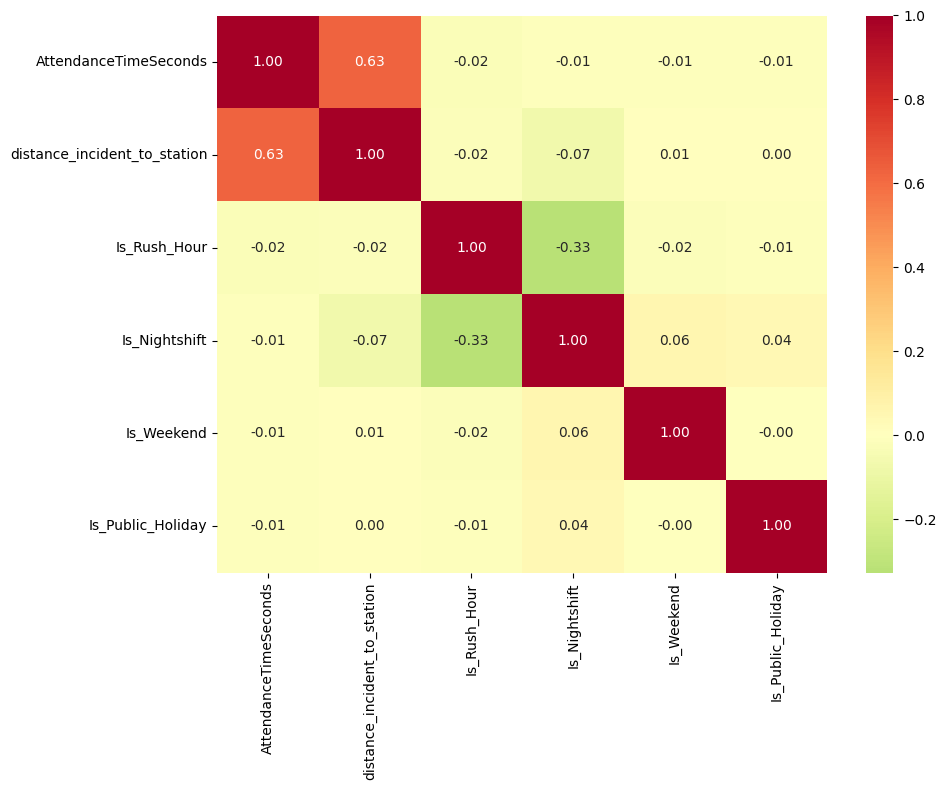

In [67]:
df_merge_neu = df_merge_neu.rename(columns={'distance_fire_to_station': 'distance_incident_to_station'})
# 1. Filtern: Nur Kredite/Einsätze mit plausibler Distanz (> 20)
df_heatmap = df_merge_neu[df_merge_neu['distance_incident_to_station'] > 20].copy()

# 2. Auswahl der Features für die Heatmap
# (Hier alle relevanten engineered features + target)
features = [
    'AttendanceTimeSeconds', 
    'distance_incident_to_station', 
    'Is_Rush_Hour', 
    'Is_Nightshift', 
    'Is_Weekend', 
    'Is_Public_Holiday'
]

# 3. Korrelation berechnen
corr_matrix = df_heatmap[features].corr()

# 4. Heatmap plotten
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn_r', fmt=".2f", center=0)

#plt.title('Figure 8: Updated Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('Figure_8_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [65]:
df_merge_neu.info()

<class 'pandas.DataFrame'>
RangeIndex: 608941 entries, 0 to 608940
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   IncidentNumber            608941 non-null  str    
 1   CalYear                   608941 non-null  int64  
 2   Month                     608941 non-null  int64  
 3   Weekday                   608941 non-null  int64  
 4   Hour                      608941 non-null  int64  
 5   Is_Nightshift             608941 non-null  int64  
 6   Is_Rush_Hour              608941 non-null  int64  
 7   Is_Weekend                608941 non-null  int64  
 8   Is_Public_Holiday         608941 non-null  int64  
 9   AttendanceTimeSeconds     608941 non-null  int64  
 10  DeployedFromStation_Name  608941 non-null  str    
 11  PumpOrder                 608941 non-null  int64  
 12  IncidentGroup             608941 non-null  str    
 13  Is_SpecialService         608941 non-null  int64  
 14 

In [ ]:
first_pump = df[df['PumpOrder'] == 1]
hourly_stats = first_pump.groupby('HourOfCall')['AttendanceTimeSeconds'].mean()

# Visualisierung
plt.figure(figsize=(12, 6))
sns.lineplot(x=hourly_stats.index, y=hourly_stats.values, marker='o', color='teal', linewidth=2)

plt.title('Durchschnittliche Eintreffzeit (Erstes Fahrzeug: PumpOrder=1)', fontsize=14)
plt.xlabel('Stunde des Anrufs (0-23)', fontsize=12)
plt.ylabel('Durchschnittliche Zeit (Sekunden)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()